# **<span style="color:#66CCFF">Walkthrough Notebook:**</span> How to Use *Sympy.py* to Expand a Higher Order Harmonic Series to Model Harmonic Currents in Potentiostatic EIS/NLEIS Experiments
#### Author: Lauren Frank (Last Updated: March 28th, 2025)



In [55]:
import sympy as sp
from sympy.functions.elementary.trigonometric import TrigonometricFunction
from tqdm import tqdm

## <ins>2. Series Expansion</ins>

#### The following example will be creating a <ins>4th-ordered current model</ins>; however, additional information will be provided for how to implement this workflow using a higher ordered series (i.e 6th-order), where a few minor modifications are needed in order to run the notebook due to timeout errors.

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;a. Define System Variables

In [ ]:
#Define System Variables
w, t, a, f, E, C_11, C_13, C_22, C_24, C_3, C_4, c_b, phase_1, phase_2, phase_3, phase_4 = sp.symbols(r'\omega t a f E C_{11}^{S} C_{13}^{S} C_{22}^{S} C_{24}^{S} C_{3}^{S} C_{4}^{S} c^{b} \phi_1 \phi_2 \phi_3 \phi_4',real=True)
sp.init_printing(use_unicode=True) #prints terms in series using a human-readable format

#Sympy Fraction
one_half = sp.Rational(1, 2) #needed to avoid solutions having decimal notation

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;b. Define 4th-Ordered Series

$$
\sum = \frac{(C_{11}^S + C_{13}^S)}{c^b} * cos(\omega t) +
    \frac{(C_{22}^S + C_{24}^S)}{c^b} * cos(2\omega t) +
    \frac{C_{3}^S}{c^b} * cos(3\omega t) +
    \frac{C_{4}^S}{c^b} * cos(4\omega t) \\
\frac{c^{III,s}}{c^{III,s}} = (1+\sum)(1+a*\sum + (a*\sum)^2 + (a*\sum)^3 + (a*\sum)^4)
$$

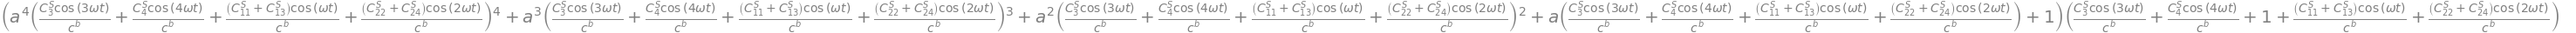

In [162]:
# Summation Term (∑) - Equation 9
E_eq = (
    (C_11 + C_13) / c_b  * sp.cos(w*t) +
    (C_22 + C_24) / c_b * sp.cos(2*w*t) +
    C_3 / c_b * sp.cos(3*w*t) +
    C_4 / c_b * sp.cos(4*w*t)
)
#Concentration Ratio - Equation 10
series = (1 + E_eq) * (1 + a*E_eq + (a*E_eq)**2 + (a*E_eq)**3 + (a*E_eq)**4)
series

### c. Sympy Expansion of Concentration Ratio

In [163]:
series_expanded = sp.expand(series) #Sympy expansion of multiplication
series_expanded_terms = series_expanded.as_ordered_terms() #puts the terms from the expanded series into a list

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<ins>For context</ins>, see the first 25 expanded terms in the series:

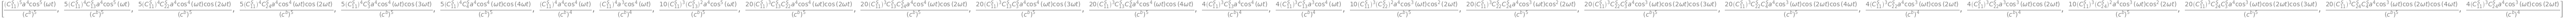

In [164]:
series_expanded_terms[0:25]

### Converting to Trig Functions

##### Uses Power-reduction formulae: https://en.wikipedia.org/wiki/List_of_trigonometric_identities

In [61]:
def is_done(powers_dict, trig_terms):
    if len(trig_terms) == 0:
        return True
    if len(trig_terms) == 1:
        trig_term = list(trig_terms)[0]
        exponent = powers_dict[trig_term]
        if exponent == 1:
            return True
        else:
            return False
    else:
        return False

In [62]:
def inner_sum(a, k, var):
    return sp.binomial(a, k) * sp.cos((a - 2*k) * var)
def compute_cosine(a,var): 
    if a % 2 == 0:
        end = a//2 - 1
        constant = sp.binomial(a, a//2) / 2**a
    else:
        end = (a - 1)//2
        constant = 0
    sum = 0
    for k in range(0,end+1):
        sum += inner_sum(a,k,var)
    return  constant + sum / 2**(a - 1)

In [138]:
def convert_term(term_input):

    #Break Apart Series into Separate Calculations
    all_terms = term_input.as_ordered_terms()
    if len(all_terms) > 1:
        return convert_term(all_terms[0]) + convert_term(sum(all_terms[1:]))
    
    #Single Term, No Series
    powers_dict = term_input.as_powers_dict()
    trig_terms = term_input.atoms(TrigonometricFunction)
    if is_done(powers_dict,trig_terms) == True:
        return term_input
    elif len(trig_terms) == 1: #cos^a(x) term type
        trig_term = list(trig_terms)[0]
        in_parenthesis = trig_term.args[0]
        trig_exponent = powers_dict[trig_term]
        expanded_terms = compute_cosine(trig_exponent,in_parenthesis)
        other_terms = 1
        for key in powers_dict:
            if key not in trig_terms:
                other_terms *= key ** powers_dict[key]
        return convert_term((expanded_terms * other_terms).expand())
    elif len(trig_terms) > 1: #2+ cosines multiplying each other
        trig_expanded_term = sp.expand_trig(term_input).expand()
        return convert_term(trig_expanded_term)
    else:
        print("Error: base case was not reached. Check to see if there are other cases.")

In [64]:
def check_sol(term1, term2):
    return sp.simplify(sp.expand_trig(term1) - sp.expand_trig(term2))

In [165]:
converted_terms = []
for term in tqdm(series_expanded_terms, desc="Converting terms"):
    converted_terms.append(convert_term(term))

Converting terms: 100%|██████████| 671/671 [00:05<00:00, 112.46it/s]


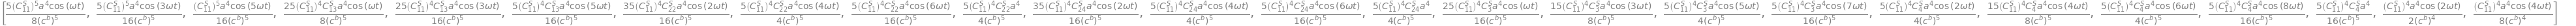

In [66]:
converted_series = sum(converted_terms)
converted_series.as_ordered_terms()[0:25]

In [67]:
len(converted_series.as_ordered_terms())

In [68]:
check_mask = [-1]*len(series_expanded_terms)
count = 0
for term1 in tqdm(series_expanded_terms, desc="Converting terms"):
    term2 = converted_terms[count]
    res = check_sol(term1, term2)
    check_mask[count] = res
    count += 1
unique_values = set(check_mask)
print("Unique{Original Terms - Converted Terms}:")
print(unique_values)

Converting terms: 100%|██████████| 671/671 [00:23<00:00, 29.15it/s]

Unique{Original Terms - Converted Terms}:
{0}


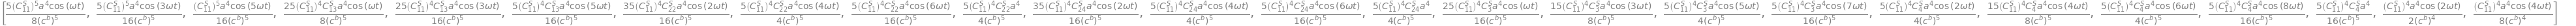

In [69]:
converted_final_terms = converted_series.as_ordered_terms()
converted_final_terms[0:25]

## <ins>3. Surface Concentration Coefficient Filtering and Sorting</ins>

#### As explained before, each $C_{j,k}^{s,III}$ coefficient is of order $∆E^k$. For example, in the first harmonic $(e^{i\omega t} + e^{-i\omega t})$, $C_{1,1}^{s,III}$ is of the power $\Delta E^1$ where $C_{1,3}^{s,III}$ is of the power $\Delta E^3$. However, upon expansion of the series in Equation 10, these coefficients are mixed together when distributed amongst the parentheses through multiplication. In order to solve for these coefficients, the total $\Delta E^k$ power of each term in the expanded series needs to be evaluated. Moreover, the multiplication and raising of exponents for each of the individual coefficients needs to also be accounted for.

#### To do so, the terms corresponding to each harmonic were filtered into separate bins, where terms were removed if $k > N$ (i.e., 4th order, 6th order expansion terms), or if the multiplied harmonic $(e^{ij\omega t} + e^{-ij\omega t})$ had a number $j$ greater than this desired series order. See functions `filter_series` for how to remove h.o.t. terms and `sort_harmonics` for how to bin the filtered expansion terms based on their harmonic j:

In [70]:
def filter_series(terms_list, N, wt_dict):
    
    '''
    Modifies an ordered set of terms by deleting h.o.t. (i.e O(term) > O(∆E^N) and j > N)
    
    Args:
        terms_list (list): ordered terms from expanded series
        N (int): highest ordered harmonic terms to keep (e.g. up to 4th order... N = 4)
        wt_dict (dict): dictionary where the keys are the sympy representations of each concentration coefficient
                        (e.g. C_11, C_3, etc.) and the values are the weights (∆E^k) of the different harmonics (e.g. C_11 = 1, C_3 = 3)
    
    Return:
        res (list): list of filtered terms
    '''
    
    res = []
    deleted = []
    for term in terms_list:
        
        #Dictionary with base numbers as keys and exponents as values (e.g. C_11^2 * C_24^3 * a^2 ==> keys: C_11, C_24, a; values: 2, 3, 2)
        powers_dict = term.as_powers_dict()
        trig_terms = term.atoms(TrigonometricFunction)
        harmonic = -1
        
        if len(trig_terms) != 0:

            trig_term = list(trig_terms)[0]
            harmonic = int(trig_term.args[0]/(w*t))

            if harmonic > N:
                deleted.append(term)
                continue #removes terms with exponentials greater than n (j > n)
        
        #Calculates the Total ∆E^k of each Term
        pow = 0
        for key in powers_dict:
            temp_key = str(key) #converts Sympy representation of variable to explicit string
            if temp_key in wt_dict:
                wt = wt_dict[temp_key] #∆E^k weight (e.g C_24 ==> wt = 4)
                exp = powers_dict[key] #Raised Exponent of Term (e.g. C_24^3 ==> exp = 3)
                pow += wt * exp #∆E^(k_1*exp_1) * #∆E^(k_2*exp_2) * .... #∆E^(k_i*exp_i)  ==>  k power = (k_1*exp_1) + (k_2*exp_2) + ... (k_i*exp_i)              
        if pow <= N:
            res.append(term) #Adds terms only if the summed exponents (k) is less than / equal to 'N'  
        else:
            deleted.append(term)
    return res,deleted

In [71]:
def sort_harmonics(filtered_terms):
        
    '''
    Sorts the different terms into respective harmonic bins via a dictionary [keys are const, 1, 2, 3, ...; values are series of terms]
    
    Args:
        filtered_terms (list): list containing the terms that have been filtered
    
    Return:
        res_dict (dict): dictionary containing the sorted terms with exponentials still attatched
    
    '''
    
    res_dict = {"const":[]}
    for term in filtered_terms:
        
        #Dictionary with base numbers as keys and exponents as values (e.g. C_11^2 * C_24^3 * a^2 ==> keys: C_11, C_24, a; values: 2, 3, 2)
        trig_terms = term.atoms(TrigonometricFunction) 
        
        if len(trig_terms) != 0:

            trig_term = list(trig_terms)[0]
            harmonic = int(trig_term.args[0]/(w*t))

            if harmonic in res_dict:
                val = res_dict[harmonic]
                res_dict[harmonic] = val + [term] #adds term to existing harmonic series
            else:
                res_dict[harmonic] = [term] #creates first term in new harmoinc series
        else:
            res_dict["const"] += [term] #adds to const bin if no harmonic contribution detected
                
    return res_dict
        

#### After sorting the terms into separate bins for each harmonic (i.e., constants, 1, 2, 3, ...) based on the multiplied exponential $e^{ij\omega t}$ or $e^{-ij\omega t}$, exponential pairs $(e^{ij\omega t} + e^{-ij\omega t})$ were reformed and used to extract the leading coefficients (the summed inner terms). See function `get_coeff` below for this process:

In [72]:
def get_coeff(terms,harm):
    
    '''
    Extracts the coefficients of each harmonic by combining (+) and (-) exponent pairs and factoring out the constants in front of each into a list
    
    Args:
        terms (list): specific list of harmonic terms from res_dict at a single harmonic
        harm (int): harmonic number that alligns with the provided terms
    
    Return:
        coeff_list (list): list of coefficients for the specified harmonic termed list
    
    '''
    
    coeff_list= []
    for term in terms:
        coeff = sp.simplify(term / sp.cos(harm * w * t))
        coeff_list.append(coeff)
    
    return coeff_list## Expansion + Filtering

#### Within each set of inner terms for a specific harmonic $\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_j$, each term can have a different $∆E^k$ power (e.g. first harmonic terms => $∆E^1$, $∆E^3$, $\ldots$). To further characterize these harmonics, the terms with different $∆E^k$ power are also separated in order to find the oscillating grouped terms $\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{j,k}$ for each harmonic $j$ and modulation power $k$. See function `sep_coeff` for this process:

In [73]:
def sep_coeff(coeff_list, wt_dict):

    '''
    Creates a dictionary from a coeff_list, where the keys are the different total powers, k,
    of the terms and the values are lists containing the terms with those total powers. 
    This is used to extract/seperate the different contribution terms from a single harmonic 
    (e.g first harmonic - extract its first order (∆E^1) and third order (∆E^3) contributions separately).
    
    Args:
        coeff_list (list): list of coefficients for a single harmonic (output of get_coeff) (e.g )
        wt_dict (dict): dictionary where the keys are the differnt variables in the system 
        (e.g. C_3, C_3, etc.) and the values are the weights (∆E^w) of the different harmonics (e.g. C_3 = 3)
    
    Return:
        res_dict (dict): dictionary containing the terms of the coeff_list separated by keys 
        representing the harmonic totals
    
    '''
    
    res_dict = {}
    for coeff in coeff_list:
        
        powers_dict = coeff.as_powers_dict()
        pow = 0
        for key in powers_dict:
            temp_key = str(key)
            if temp_key in wt_dict:
                wt = wt_dict[temp_key]
                exp = powers_dict[key]
                pow += wt * exp
                
        if pow not in res_dict:
            res_dict[pow] = [coeff]
        else:
            val = res_dict[pow]
            res_dict[pow] = val + [coeff]    
            
    return res_dict
        

### <ins>★ To further understand how to use these functions, see the below example for the 4th-order series:</ins>

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;a. Extracted Grouped Oscillating Harmonic Terms $\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_j$ (before filtering of $∆E^k$ within each Harmonic)

In [74]:
#k value of ∆E^k for Single C_i
wt_dict = {
    'C_{11}^{S}':1,
    'C_{13}^{S}':3,
    'C_{22}^{S}':2,
    'C_{24}^{S}':4,
    'C_{3}^{S}':3,
    'C_{4}^{S}':4,
}

# Removes higher order terms (> N = 4)
filtered_terms,deleted_terms = filter_series(converted_final_terms,4,wt_dict)

#Sorts the Terms (Consts and Exponentials) into Different Harmonics (Exponentials still in terms)
harmonic_dict = sort_harmonics(filtered_terms)

#Extracts the Coefficients of Each Harmonic in front of the Exponential Pairs (e.g C_1*e^iwt + C_1*e^-iwt --> returns C_1 in first harmonic list)
term_1_series = get_coeff(harmonic_dict[1],1) #first harmonic
term_2_series = get_coeff(harmonic_dict[2],2) #second harmonic
term_3_series = get_coeff(harmonic_dict[3],3) #third harmonic
term_4_series = get_coeff(harmonic_dict[4],4) #fourth harmonic
const_series = harmonic_dict["const"] #constant

$\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_0$ =

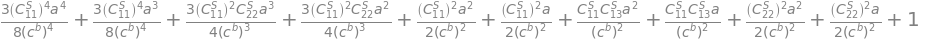

In [75]:
sum(const_series)

$\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_1$ =

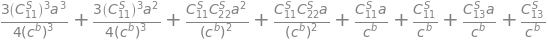

In [76]:
sum(term_1_series)

$\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_2$ =

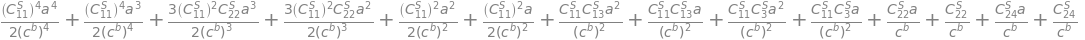

In [77]:
sum(term_2_series)

$\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_3$ =

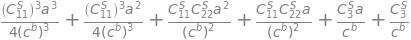

In [78]:
sum(term_3_series)

$\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_4$ =

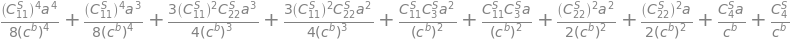

In [79]:
sum(term_4_series)

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;b. Separation of Extracted Harmonic Terms based on $∆E^k$ Powers $\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{j,k}$

In [80]:
#Finds the unique k powers within a specific harmonic list and assigns each term accordingly (E.g. 1st harmonic --> ∆E^1 and ∆E^3 terms)
const_terms = sep_coeff(const_series, wt_dict)
const_2 = const_terms[2]
const_4 = const_terms[4]

term1_terms = sep_coeff(term_1_series,wt_dict)
term_1_1 = term1_terms[1]
term_1_3 = term1_terms[3]

term2_terms = sep_coeff(term_2_series,wt_dict)
term_2_2 = term2_terms[2]
term_2_4 = term2_terms[4]

#Re-stating Variable as series does not need to be separated
term_3 = term_3_series
term_4 = term_4_series

$\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{0,2}$ =

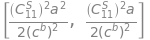

In [81]:
const_2

$\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{0.4}$ =

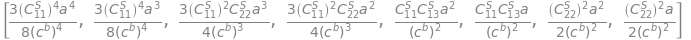

In [82]:
const_4

$\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{1,1}$ =

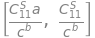

In [83]:
term_1_1

$\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{1,3}$ =

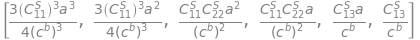

In [84]:
term_1_3

$\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{2,2}$ =

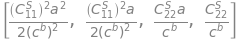

In [85]:
term_2_2

$\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{2,4}$ =

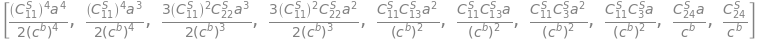

In [86]:
term_2_4

$\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{3}$ =

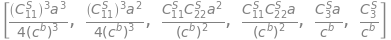

In [87]:
term_3

$\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{4}$ =

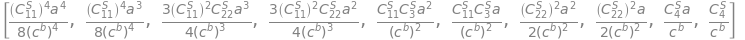

In [88]:
term_4

## <ins>4. Solving the Coefficients Expressions (Nernst Expansion + Oscillating Concentration Expansion)</ins>

#### The coefficient expressions found from the Oscillating Concentration Expansion (Equation 12) were set equal to corresponding coefficients from the expanded Nernst Equation (Equation 3) to identify the individual harmonic surface concentration coefficients $C_{j,k}^{s,III}$. This system was solved using the Sympy Analytical Solver.

#### a. Nernst Expansion for N = 4, following Equation 3:

#### MacLaurin Series
$$
e^{f (E_n - E_0)} = \sum_{k=0}^{\infty} \frac{\left[f (E_n - E_0)\right]^k}{k!} = 1 + f (E_n - E_0) + \frac{\left[f (E_n - E_0)\right]^2}{2!} + \frac{\left[f (E_n - E_0)\right]^3}{3!} + \cdots \tag{15}
$$


In [ ]:
#E_n - E_0
input_modulation_E = E * sp.cos(w*t)
exp_expr = f * input_modulation_E

#Factorial Fractions from MacLaurin Series
frac_2 = sp.Rational(1,sp.factorial(2))
frac_3 = sp.Rational(1,sp.factorial(3))
frac_4 = sp.Rational(1,sp.factorial(4))

#MacLaurin Series Expansion of exp(f * input modulation)
E_Nernst = (
    1 + exp_expr + #constant + 1
    exp_expr**2 * frac_2 + #2
    exp_expr**3 * frac_3 + #3
    exp_expr**4 * frac_4  #4
    # . . .  keep adding terms to desired expansion order, N
)

#Resulting Expansion
Nernst_expanded = sp.expand(E_Nernst)
Nernst_expanded_terms = sum([convert_term(x) for x in Nernst_expanded.as_ordered_terms()]).as_ordered_terms()
Nernst_sorted_terms = sort_harmonics(Nernst_expanded_terms)

#Extracts the Coefficients of Each Harmonic / Sorts Each in Order of Increasing k (for ∆E^k)
term_1_Nernst_series = sorted(get_coeff(Nernst_sorted_terms[1],1),key=lambda term: sp.degree(term, E)) #first harmonic
term_2_Nernst_series = sorted(get_coeff(Nernst_sorted_terms[2],2),key=lambda term: sp.degree(term, E)) #second harmonic
term_3_Nernst_series = get_coeff(Nernst_sorted_terms[3],3) #third harmonic
term_4_Nernst_series = get_coeff(Nernst_sorted_terms[4],4) #fourth harmonic
const_Nernst = sorted(Nernst_sorted_terms["const"],key=lambda term: sp.degree(term, E)) #constant

#Resulting Nernst Terms
term_1_1_Nernst = term_1_Nernst_series[0]
term_1_3_Nernst = term_1_Nernst_series[1]
term_2_2_Nernst = term_2_Nernst_series[0]
term_2_4_Nernst = term_2_Nernst_series[1]
term_3_Nernst = term_3_Nernst_series[0]
term_4_Nernst = term_4_Nernst_series[0]

### Resulting Inner Terms for Nernst Expansion (Equation 3) using New Notation:
$$
\frac{c^{s,III}}{c^{s,II}} =
\underbrace{\left[1 + \frac{f^2 \Delta E^2}{4} + \ldots \right]}_{\text{Constant Term}} +
\underbrace{\left[ T_{11,Nernst} +  T_{13,Nernst} + \ldots \right]}_{\text{1st Harmonic Term}} * cos(\omega t) +
\underbrace{\left[ T_{22,Nernst} +  T_{24,Nernst} + \ldots \right]}_{\text{2nd Harmonic Term}} * cos(2\omega t) + \ldots \tag{16}
$$

In [92]:
term_1_1_Nernst

In [93]:
term_1_3_Nernst

In [94]:
term_2_2_Nernst

In [95]:
term_2_4_Nernst

In [96]:
term_3_Nernst

In [97]:
term_4_Nernst

### b. Analytical Solver

In [98]:
#Equations (1-8) - Setting Each Grouped Oscilalting Terms Equal to the Respective Nernst Term
eq1 = sp.Eq(sum(term_1_1), term_1_1_Nernst) #C_11
eq2 = sp.Eq(sum(term_1_3), term_1_3_Nernst) #C_13
eq3 = sp.Eq(sum(term_2_2), term_2_2_Nernst) #C_22
eq4 = sp.Eq(sum(term_2_4), term_2_4_Nernst) #C_24
eq5 = sp.Eq(sum(term_3), term_3_Nernst) #C_3
eq6 = sp.Eq(sum(term_4), term_4_Nernst) #C_4

#Solver
sol = sp.solve([eq1, eq2, eq3, eq4, eq5, eq6], [C_11, C_13, C_22, C_24, C_3, C_4], real = True)
solution_tuple = sol[0]
C_11_sol, C_13_sol, C_22_sol, C_24_sol, C_3_sol, C_4_sol = solution_tuple

$ C_{1,1}^{s,III}$ =

In [99]:
C_11_sol

$ C_{1,3}^{s,III}$ =

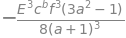

In [100]:
C_13_sol

$ C_{2,2}^{s,III}$ =

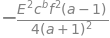

In [101]:
C_22_sol

$ C_{2,4}^{s,III}$ =

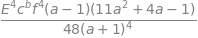

In [102]:
C_24_sol

$ C_{3}^{s,III}$ =

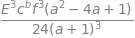

In [103]:
C_3_sol

$ C_{4}^{s,III}$ =

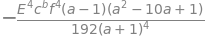

In [104]:
C_4_sol

## <ins>5. Determining the Models for Current</ins>

#### Finally, the surface concetration coefficients $C_{j}^{s,III}$ were used to determine the harmonic currents. To do so, the results were substituted into the equation for current (Equation 14), along with the relationships for $D^{III}$, $f$, and $a$ (per Frank et al.):
$$
\widetilde{I}_{j} = FAC_{j}^{s,III}\sqrt{\frac{j \omega D^{III}}{2}}(1+i) \tag{17}
$$
$$
D^{III} = D^0*(1+\delta) \tag{18}
$$
$$
f = \frac{F}{RT} \tag{19}
$$
$$
a = \sqrt{\frac{D^{III}}{D^{II}}} \approx 1+\delta \tag{20}
$$

#### Defining Variable Substitutions and Current Equation

I_generalForm =


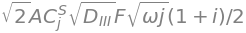

In [188]:
#Defining New Variables
F,A,R,T,D_III,j,C_T, D_0, δ = sp.symbols('F A R T D_III j C_j^S D_0 δ',real=True) #C_T is the temporary surface concentration ratio w/ respect to C_0

#Defining Expressions to Substitute In
a_expr = (1 + δ)
D_III_expr = D_0 * a
f_expr = F/(R*T)
I_expr = F * A * (D_III*one_half)**(one_half) * ((1 + sp.I) * (j * w)**(one_half)) * C_T
I_expr = sp.collect(I_expr, j * w)
print("I_generalForm =")
I_expr

where $C_j^S$ represents the temporary placeholder (C_T) for a substituted concentration coefficient.

$ \text{First Harmonic Current } \widetilde{I}_{1} $

I_1 =


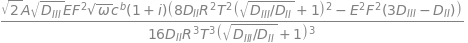

In [197]:
#Substitutions for f
C_11_sol_sub = C_11_sol.subs(f,f_expr)
C_13_sol_sub = C_13_sol.subs(f,f_expr)
D_II = sp.symbols(r"D_{II}",real=True)
a_sub = sp.sqrt(D_III / D_II)

#Substitutions of 'C_T' and other variable expressions into Current Equation
I_1 = I_expr.subs({C_T: C_11_sol_sub+C_13_sol_sub, j: 1,a:a_sub})
I_1 = sp.simplify(I_1)

print("I_1 =")
I_1

$ \text{Second Harmonic Current } \widetilde{I}_{2} $

I_2 =


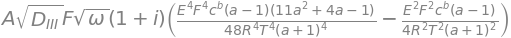

In [192]:
#Substitutions for f
C_22_sol_sub = C_22_sol.subs(f,f_expr)
C_24_sol_sub = C_24_sol.subs(f,f_expr)

#Substitutions of 'C_T' and other variable expressions into Current Equation
I_2 = I_expr.subs({C_T: C_22_sol_sub+C_24_sol_sub, j: 2})

print("I_2 =")
I_2

$ \text{Third Harmonic Current } \widetilde{I}_{3} $

I_3 =


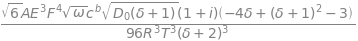

In [108]:
#Substitutions for f
C_3_sol_sub = C_3_sol.subs(f,f_expr)

#Substitutions of 'C_T' and other variable expressions into Current Equation
I_3 = I_expr.subs({C_T: C_3_sol_sub, j: 3,D_III: D_III_expr, a:a_expr})

print("I_3 =")
I_3

#### **<span style="color:tomato;">★ Finally</span>**: These models ($\tilde{I}_j$) were then simplified outside of the notebook using a MacLaurin Series Expansion of the denominator of each term for the ${(δ+x)}^n$, where the term ${(1 + αδ)}^n$ can be approximated as $(1 + nαδ)$ when $δ << 1$ and $α$ is a constant (which is true for this case). See this below for the first and second harmonic currents:

### First Harmonic (j = 1):
$$
\tilde{I}_1 = AFc^b\sqrt{\frac{\omega D^0}{2}}(1+i)\left[
\underbrace{
\frac{-\Delta E^3 F^3 \left(3(\delta+1)^2 - 1\right)}{8 R^3 T^3 (\delta + 2)^3}
}_{\text{\normalsize Group \raisebox{.5pt}{\textcircled{\raisebox{-.9pt} {1}}}}}
+
\underbrace{
\frac{\Delta E F}{R T (\delta + 2)}
}_{\text{\normalsize Group \raisebox{.5pt}{\textcircled{\raisebox{-.9pt} {2}}} }}
\right]
$$
$$
\text{\raisebox{.5pt}{\textcircled{\raisebox{-.9pt} {1}}} } \frac{-\Delta E^3 F^3 \left(3(\delta+1)^2 - 1\right)}{8 R^3 T^3 (\delta + 2)^3}
$$
$$
\big\Downarrow \\
(\delta + 2)^{-3} = \frac{1}{2^3(0.5\delta+1)^3} \approx \frac{1}{8}(1-3(0.5\delta))
$$
$$
(\delta + 1)^{2} =  1 + 2\delta \\
\big\Downarrow
$$
$$
= \frac{-\Delta E^3 F^3 \left(3 \overset{\scriptstyle \color{red}{1\ since \ \delta<<0}}{\cancel{(1+2\delta)}} - 1\right) (1- \overset{\scriptstyle \color{red}{0\ since \ \delta<<0}}{\cancel{3(0.5\delta)}})}{64 R^3 T^3}
$$
$$
\boxed{\text{\raisebox{.5pt}{\textcircled{\raisebox{-.9pt} {1}}} }=\frac{-\Delta E^3 F^3}{32 R^3 T^3}}
$$
$$
\\[2em]
\text{\raisebox{.5pt}{\textcircled{\raisebox{-.9pt} {2}}} } \frac{\Delta E F}{R T (\delta + 2)}
$$
$$
\big\Downarrow \\
(\delta + 2)^{-1} = \frac{1}{2(0.5\delta+1)} \approx \frac{1}{2}(1-0.5\delta)
$$
$$
\big\Downarrow
$$
$$
=\frac{\Delta E F \overset{\scriptstyle \color{red}{1\ since \ \delta<<0}}{\cancel{(1-0.5\delta)}}}{2RT}
$$
$$
\boxed{\text{\raisebox{.5pt}{\textcircled{\raisebox{-.9pt} {1}}} }= \frac{\Delta E F}{2RT}}
$$

$$
\\[2em]
 \therefore \ \tilde{I}_1 = \frac{FAc^b}{2}\sqrt{\frac{D^0*\omega}{2}}*(1+i)*\left[1 - \frac{∆E^2F^2}{16R^2T^2} \right] * \frac{F∆E}{RT}
$$


### Second Harmonic (j = 2):
$$
\tilde{I}_2 = AFc^b\sqrt{\omega D^0}(1+i)\left[\underbrace{\frac{∆E^4F^4\delta(4\delta+11(\delta+1)^2+3)}{48R^4T^4(\delta+2)^4}}_{\text{\normalsize Group \raisebox{.5pt}{\textcircled{\raisebox{-.9pt} {3}}} }}-\underbrace{\frac{∆E^2F^2\delta}{4R^2T^2(\delta+2)^2}}_{\text{\text{\normalsize Group \raisebox{.5pt}{\textcircled{\raisebox{-.9pt} {4}}} }}}\right]
$$
$$
\text{\raisebox{.5pt}{\textcircled{\raisebox{-.9pt} {3}}} } \frac{∆E^4F^4\delta(4\delta+11(\delta+1)^2+3)}{48R^4T^4(\delta+2)^4}
$$
$$
\big\Downarrow \\
(\delta + 2)^{-4} = \frac{1}{2^4(0.5\delta+1)^4} \approx \frac{1}{16}(1-4(0.5\delta))
$$
$$
(\delta + 1)^{2} =  1 + 2\delta \\
\big\Downarrow
$$
$$
=\frac{∆E^4F^4\delta(4\delta+11(1+2\delta)+3)\overset{\scriptstyle \color{red}{1\ since \ \delta<<0}}{\cancel{(1-4(0.5\delta))}}}{768R^4T^4}
$$
$$
=\frac{∆E^4F^4\delta(4\delta+11+22\delta+3)}{768R^4T^4}
$$
$$
=\frac{∆E^4F^4\delta(26\delta+14)}{768R^4T^4}
$$
$$
=\frac{∆E^4F^4\delta(13\delta+7)}{384R^4T^4}
$$
$$
=\frac{∆E^4F^4\delta*7\overset{\scriptstyle \color{red}{1\ since \ \delta<<0}}{\cancel{(\frac{13}{7}\delta+1)}}}{384R^4T^4}
$$
$$
\boxed{\text{\raisebox{.5pt}{\textcircled{\raisebox{-.9pt} {3}}} }=\frac{7\Delta E^4 F^4 \delta}{384 R^4 T^4}}
$$
$$
\\[2em]
\text{\raisebox{.5pt}{\textcircled{\raisebox{-.9pt} {4}}} } \frac{∆E^2F^2\delta}{4R^2T^2(\delta+2)^2}
$$
$$
\big\Downarrow \\
(\delta + 2)^{-2} = \frac{1}{4(0.5\delta+1)^{2}} \approx \frac{1}{4}(1-2(0.5\delta))
$$
$$
\big\Downarrow
$$
$$
=\frac{∆E^2F^2\delta \overset{\scriptstyle \color{red}{1\ since \ \delta<<0}}{\cancel{(1-2(0.5\delta))}}}{16R^2T^2}
$$
$$
\boxed{\text{\raisebox{.5pt}{\textcircled{\raisebox{-.9pt} {4}}} }= \frac{\Delta E^2F^2\delta}{16R^2T^2}}
$$

$$
\\[2em]
 \therefore \ \tilde{I}_2 = - \delta * \frac{FAc^b}{16}\sqrt{D^0*\omega}*(1+i)*\left[1 - \frac{7*∆E^2F^2}{24R^2T^2} \right] * \frac{F^2∆E^2}{R^2T^2}
$$

## <ins>6. Summary Results (2nd, 4th, and 6th Order)</ins>

#### Continuing this analysis to the sixth-order (N=6), the concentration coefficient results were tabulated:

<center>

| **Harmonic Order $j$** | **Modulation Order $k$** | **Coefficient $C_{j,k}^{s,III}$**                            | **Model Order $N$** |
|:----------------------:|:------------------------:|:------------------------------------------------------------:|:-------------------:|
|          1             |           1              | $\frac{∆Ec^bf}{a+1}$                                         |          2,4,6          |
|          2             |           2              | $-\frac{∆E^2c^bf^2(a-1)}{4(a+1)}$                            |          2,4,6          |
|          1             |           3              | $-\frac{∆E^3c^bf^3*(3a^2-1)}{8(a+1)^3}$                      |          4,6          |
|          2             |           4              | $\frac{∆E^4c^bf^4(a-1)(11a^2+4a-1)}{48(a+1)^4}$              |          4,6          |
|          3             |           3              | $\frac{∆E^3c^bf^3(a^2-4a+1)}{24(a+1)^3}$                                                  |          4,6          |
|          4             |           4              | $-\frac{∆E^4c^bf^4(a-1)(a^2-10a+1)}{192(a+1)^4}$                                                  |          4,6          |
|          1             |           5              | $\frac{∆E^5f^5(55a^4+4a^3-36a^3-8a+1)}{192(a+1)^5}$                                                  |          6          |
|          2             |           6              | $-\frac{∆E^6f^6(a-1)(353a^4+196a^3-66a^2-28a+1)}{1536(a+1)^6}$                                                  |          6          |
|          3             |           5              | $-\frac{∆E^5f^5(31a^4-62a^3-2a^2+18a-1)}{384(a+1)^5}$                                                  |          6          |
|          4             |           6              | $\frac{∆E^6f^6(a-1)(79a^4-272a^3-66a^2+46a-1)}{3840(a+1)^6}$                                                  |          6          |
|          5             |           5              | $\frac{∆E^5f^5(a^4-26a^3+66a^2-26a+1)}{1920(a+1)^5}$                                                  |          6          |
|          6             |           6              | $-\frac{∆E^6f^6(a-1)(a^4-56a^3+246a^2-56a+1)}{23040(a+1)^6}$                                                  |          6          |

</center>

#### where $f = \frac{F}{RT}$. Using a MacLaurin Series Expansion of each term from the substituted result of Equation 17 (like before), the simplified 2nd, 4th, and 6th-order <u>current models</u> were found:

<div style="text-align:center;">

#### <u>2nd-Order (N = 2)</u>:

$$
\tilde{I}_1 = \frac{FAc^b}{2}\sqrt{\frac{D^0 \cdot \omega}{2}}*(1+i)*\frac{F ∆E}{RT}
$$

$$
\tilde{I}_2 = - \delta \cdot \frac{FAc^b}{16} \sqrt{D^0 \cdot \omega}*(1+i)*\frac{F^2 ∆E^2}{R^2 T^2}
$$

$$
\tilde{I}_3 = - \frac{FAc^b}{192} \sqrt{D^0 \cdot 6\omega}*(1+i)*\frac{F^3 ∆E^3}{R^3 T^3}
$$

#### <u>4th-Order (N = 4)</u>:

$$
\tilde{I}_1 = \frac{FAc^b}{2}\sqrt{\frac{D^0 \cdot \omega}{2}}* (1+i) * \left[1 - \frac{∆E^2 F^2}{16 R^2 T^2} \right] * \frac{F ∆E}{RT}
$$

$$
\tilde{I}_2 = - \delta \cdot \frac{FAc^b}{16} \sqrt{D^0 \cdot \omega} * (1+i) * \left[1 - \frac{7 ∆E^2 F^2}{24 R^2 T^2} \right] * \frac{F^2 ∆E^2}{R^2 T^2}
$$

#### <u>6th-Order (N = 6)</u>:

$$
\tilde{I}_1 = \frac{FAc^b}{2}\sqrt{\frac{D^0 \cdot \omega}{2}}*(1+i) * \left[1 - \frac{∆E^2 F^2}{16 R^2 T^2} + \frac{∆E^4 F^4}{192 R^4 T^4} \right] * \frac{F ∆E}{RT}
$$

$$
\tilde{I}_2 = - \delta \cdot \frac{FAc^b}{16} \sqrt{D^0 \cdot \omega} * (1+i) * \left[1 - \frac{7 ∆E^2 F^2}{24 R^2 T^2} + \frac{19∆E^4 F^4}{256 R^4 T^4}\right] * \frac{F^2 ∆E^2}{R^2 T^2}
$$

</div>


#### These final models were the ones reported in Frank et. al.